# The Agent-Environment Interaction: Getting Started

This notebook presents _one possible_ approach to get you started in the agent-environment interaction exercise. You are highly encouraged to make your own decisions and deviate from this template - the more you do on your own, the more you will learn.

## General structure

We want to implement the agent-environment interface depicted in the exercise sheet. We need
* an **agent** with a random policy,
* an **environment**,
* and a procedure that lets the agent interact within the environment.

We will build each of these components incrementally and components as they are needed. We make the choice of defining a **class** for both the agent and the environment. 

For the learning procedure itself, we would eventually organise the code in a double (nested) loop; the outer one for episodes, and the inner one for steps within each episode. However, we will start looking at just **one single step**. In this step, we need to
1. observe the current state of the environment,
2. let the agent choose an action, and
3. let the environment respond by changing its state and returning a reward.

Written differently for one time step `t`, we need:

In [1]:
# state_t = environment.get_current_state()
# action_t = agent.choose_action(state_t)
# reward_t, state_t_plus_1 = environment.make_step(action_t)

We thus need an agent with a `choose_action(state_t)` method.
And we need an environment with a `get_current_state()` method and a `make_step(action_t)` method.

### The environment: a `Gridworld` class

We will distinguish between the internal state of the environment, which is hidden from the agent and the interface, and the external state, which corresponds to all the parts that are accessible to the agent. For example, we do not want the agent to know where the bomb is, but the agent has to know which actions are available.

#### The internal state of the environment
The Gridworld class has to keep track of
* the general properties of the environment, e.g., the available actions or the number of cells
* the positions of the agent, and both terminal states: the gold and the bomb
* the rewards for each cell

In order to keep things simple, we will implement a very unflexible version of the environment. For example, we will keep the dimensions of the grid, the number of bombs, and the position of the gold fixed. You can (read: should) introduce variables for all these hard-coded properties once your algorithm is working.

Let us first define a class that specifies all 

In [2]:
import numpy as np

class Gridworld:
    def __init__(self):
        self.num_rows = 5
        self.num_cols = 5
        self.num_cells = self.num_cols * self.num_rows
        self.random_move_probability = 0.2
        
        # Choose starting position of the agent randomly among the first 5 cells
        self.agent_position = np.random.randint(0, 5)
        
        # Choose position of the gold and bomb
        self.bomb_positions = np.array([18])
        self.gold_positions = np.array([23])
        self.terminal_states = np.array([self.bomb_positions, self.gold_positions])
       
        # Specify rewards
        self.rewards = np.zeros(self.num_cells)
        self.rewards[self.bomb_positions] = -10
        self.rewards[self.gold_positions] = 10
        
        # Specify available actions
        self.actions = ["UP", "RIGHT", "DOWN", "LEFT"]
        self.num_actions = len(self.actions)
    
    ## Put other methods here:
    def reset(self):
        self.agent_position = np.random.randint(0, 5)
        return self.agent_position

    def get_current_state(self):
        return self.agent_position 

    def get_available_actions(self):
        return self.actions 

    def is_terminal_state(self):
        return self.agent_position in self.terminal_states

    def make_step(self, action_index): 
        # Randomly sample action_index if world is stochastic
        if np.random.uniform(0, 1) < self.random_move_probability:
            action_indices = np.arange(self.num_actions, dtype=int)
            action_indices = np.delete(action_indices, action_index)
            action_index = np.random.choice(action_indices, 1)[0]

        action = self.actions[action_index]

        # Determine new position and check whether the agent hits a wall.
        old_position = self.agent_position
        new_position = self.agent_position
        if action == "UP":
            candidate_position = old_position + self.num_cols
            if candidate_position < self.num_cells:
                new_position = candidate_position
        elif action == "RIGHT":
            candidate_position = old_position + 1
            if candidate_position % self.num_cols > 0:  # The %-operator denotes "modulo"-division.
                new_position = candidate_position
        elif action == "DOWN":
            candidate_position = old_position - self.num_cols
            if candidate_position >= 0:
                new_position = candidate_position
        elif action == "LEFT":  # "LEFT"
            candidate_position = old_position - 1
            if candidate_position % self.num_cols < self.num_cols - 1:
                new_position = candidate_position
        else:
            raise ValueError('Action was mis-specified!')

        # Update the environment state
        self.agent_position = new_position
        
        # Calculate reward
        reward = self.rewards[self.agent_position]
        reward -= 1
        return reward, new_position


Note that we chose to specify the cells in a one-dimensional array instead of a two-dimensional array (e.g., the bomb is at position `18` and not at position `[3,3]` in a two-dimensional array). This is a completely personal choice and you could choose either option. 

#### The interface of the environment
We now want to define a method that provides any agent with the needed (and allowed!) information about the current state of the environment.

Take a minute and think about which fields among those we defined above are needed both for the RandomAgent and, later, the Q-learning agent. 

...? You found an answer? Go on.

The RandomAgent only needs the available actions (technically, only the number of available actions) to randomly choose from. The Q-learning agent will need the available actions _and_ its current position.

Let us for now focus on the random agent and define a method for the Gridworld class that returns the available actions.

In [3]:
## Add the following method to the Gridworld class definition above and re-execute 
## that cell to redefine the Gridworld class. Be careful to include the right amount
## of indentation.

    # ...
    # def get_available_actions(self):
    #     return self.actions
    
## You can delete this cell after having updated the Gridworld class

### The agent: a `RandomAgent` class

We now define a RandomAgent class with a `choose_action` method.

In [4]:
class RandomAgent():
    def choose_action(self, available_actions):
        number_of_actions = len(available_actions)
        random_action_index = np.random.randint(0, number_of_actions)
        return random_action_index

Let's test the code that we've written so far.

In [5]:
env = Gridworld()
agent = RandomAgent()

available_actions = env.get_available_actions()
print("Available_actions =", available_actions)
chosen_action = agent.choose_action(available_actions)
print("Randomly chosen action =", chosen_action)

Available_actions = ['UP', 'RIGHT', 'DOWN', 'LEFT']
Randomly chosen action = 3


Now that the agent has chosen a random action, we need the environment to respond to that action. Let us define another method for the `Gridworld` class that takes the chosen action as input, updates the internal state of the environment, and returns a reward.



In [6]:
#     # Add to Gridworld class definition
    
#     #....
#     def make_step(self, action_index): 
#         # Randomly sample action_index if world is stochastic
#         if np.random.uniform(0, 1) < self.random_move_probability:
#             action_indices = np.arange(self.num_actions, dtype=int)
#             action_indices = np.delete(action_indices, action_index)
#             action_index = np.random.choice(action_indices, 1)[0]

#         action = self.actions[action_index]

#         # Determine new position and check whether the agent hits a wall.
#         old_position = self.agent_position
#         new_position = self.agent_position
#         if action == "UP":
#             candidate_position = old_position + self.num_cols
#             if candidate_position < self.num_cells:
#                 new_position = candidate_position
#         elif action == "RIGHT":
#             candidate_position = old_position + 1
#             if candidate_position % self.num_cols > 0:  # The %-operator denotes "modulo"-division.
#                 new_position = candidate_position
#         elif action == "DOWN":
#             candidate_position = old_position - self.num_cols
#             if candidate_position >= 0:
#                 new_position = candidate_position
#         elif action == "LEFT":  # "LEFT"
#             candidate_position = old_position - 1
#             if candidate_position % self.num_cols < self.num_cols - 1:
#                 new_position = candidate_position
#         else:
#             raise ValueError('Action was mis-specified!')

#         # Update the environment state
#         self.agent_position = new_position
        
#         # Calculate reward
#         reward = self.rewards[self.agent_position]
#         reward -= 1
#         return reward, new_position

    
# ## You can delete this cell after having updated the Gridworld class

After having updated the Gridworld class with the `make_step` method, create a new Gridworld...

In [7]:
env = Gridworld()

...and execute the following cell multiple times:

In [8]:
print("Current position of the agent =", env.agent_position)
available_actions = env.get_available_actions()
print("Available_actions =", available_actions)
chosen_action = agent.choose_action(available_actions)
print("Randomly chosen action =", chosen_action)
reward, next_state = env.make_step(chosen_action)

print("Reward obtained =", reward)
print("Next state =", next_state)
print("Current position of the agent =", env.agent_position)

Current position of the agent = 4
Available_actions = ['UP', 'RIGHT', 'DOWN', 'LEFT']
Randomly chosen action = 0
Reward obtained = -1.0
Next state = 9
Current position of the agent = 9


You can now manually walk the RandomAgent through our gridworld!

Next steps include:
* Build a loop so that you do not have to manually move the agent.
* Define a new class that implements a Q-learning Agent
* ...

In [9]:
env = Gridworld()
agent = RandomAgent()


In [10]:
# you can view the change of the position of the agent in the gridworld by printing the current state of the environment before and after taking a step. 
print("Current position:", env.get_current_state())

available_actions = env.get_available_actions()
chosen_action = agent.choose_action(available_actions)

print("Chosen action index:", chosen_action)
print("Chosen action:", available_actions[chosen_action])

reward, next_state = env.make_step(chosen_action)

print("Reward:", reward)
print("Next state:", next_state)
print("Terminal:", env.is_terminal_state())

Current position: 2
Chosen action index: 1
Chosen action: RIGHT
Reward: -1.0
Next state: 3
Terminal: False


In [11]:
# here is the implementation of agent moving until it gets the reward
def run_random_episode(env, agent, max_steps=1000):
    state = env.reset()
    total_reward = 0
    trajectory = [state]

    for step in range(max_steps):
        available_actions = env.get_available_actions()
        action = agent.choose_action(available_actions)

        reward, next_state = env.make_step(action)

        total_reward += reward
        trajectory.append(next_state)

        if env.is_terminal_state():
            return total_reward, step + 1, trajectory

        state = next_state

    # to prevent the function from returning None if the maximum number of steps is reached without reaching a terminal state, we can return the total reward, the maximum number of steps, and the trajectory at the end of the function.
    return total_reward, max_steps, trajectory

In [12]:
env = Gridworld()
random_agent = RandomAgent()

total_reward, num_steps, trajectory = run_random_episode(
    env, random_agent
)

print("Trajectory:", trajectory)
print("Number of steps:", num_steps)
print("Total reward:", total_reward)
print("Final state:", trajectory[-1])

Trajectory: [4, 4, 4, 9, 8, 9, 9, 4, 9, 14, 9, 8, 7, 6, 1, 6, 11, 12, 13, 14, 14, 19, 24, 24, 24, 24, 24, 24, 19, 19, 19, 18]
Number of steps: 31
Total reward: -41.0
Final state: 18


In [13]:
num_episodes = 500
random_returns = []

for episode in range(num_episodes):
    total_reward, num_steps, trajectory = run_random_episode(
        env, random_agent
    )
    random_returns.append(total_reward)

print("Mean return:", np.mean(random_returns))

Mean return: -53.238


In [14]:
class QLearningAgent:
    def __init__(
        self,
        num_states,
        num_actions,
        epsilon=0.05,
        alpha=0.1,
        gamma=1.0
    ):
        self.num_states = num_states
        self.num_actions = num_actions

        self.epsilon = epsilon
        self.alpha = alpha
        self.gamma = gamma

        
        self.q_values = np.zeros((num_states, num_actions))

    def choose_action(self, state):
        # Exploration：randomly explore
        if np.random.random() < self.epsilon:
            return np.random.randint(self.num_actions)

        # Exploitation：select the action with the highest Q-value
        state_q_values = self.q_values[state]
        best_actions = np.flatnonzero(
            state_q_values == np.max(state_q_values)
        )

        # If multiple actions are tied for the highest Q-value, randomly select one
        return np.random.choice(best_actions)

    def update(
        self,
        state,
        action,
        reward,
        next_state,
        done
    ):
        old_q_value = self.q_values[state, action]

        if done:
            target = reward
        else:
            best_next_q = np.max(self.q_values[next_state])
            target = reward + self.gamma * best_next_q

        self.q_values[state, action] = (
            old_q_value
            + self.alpha * (target - old_q_value)
        )

In [15]:
def train_q_learning(
    env,
    agent,
    num_episodes=10000,
    max_steps=5000
):
    episode_returns = []

    for episode in range(num_episodes):
        state = env.reset()
        total_reward = 0

        for step in range(max_steps):
            action = agent.choose_action(state)

            reward, next_state = env.make_step(action)
            done = env.is_terminal_state()

            agent.update(
                state,
                action,
                reward,
                next_state,
                done
            )

            total_reward += reward
            state = next_state

            if done:
                break

        episode_returns.append(total_reward)

    return np.array(episode_returns)

In [16]:
q_env = Gridworld()

q_agent = QLearningAgent(
    num_states=q_env.num_cells,
    num_actions=q_env.num_actions,
    epsilon=0.05,
    alpha=0.1,
    gamma=1.0
)

q_learning_returns = train_q_learning(
    q_env,
    q_agent,
    num_episodes=500
)

print("First 10 returns:")
print(q_learning_returns[:10])

print("Last 10 returns:")
print(q_learning_returns[-10:])

First 10 returns:
[-144.  -50.  -45.  -19.  -52.  -44. -121.  -18.  -75.  -15.]
Last 10 returns:
[  0. -10.   1.   4.   1.  -1. -16. -15.   1.   2.]


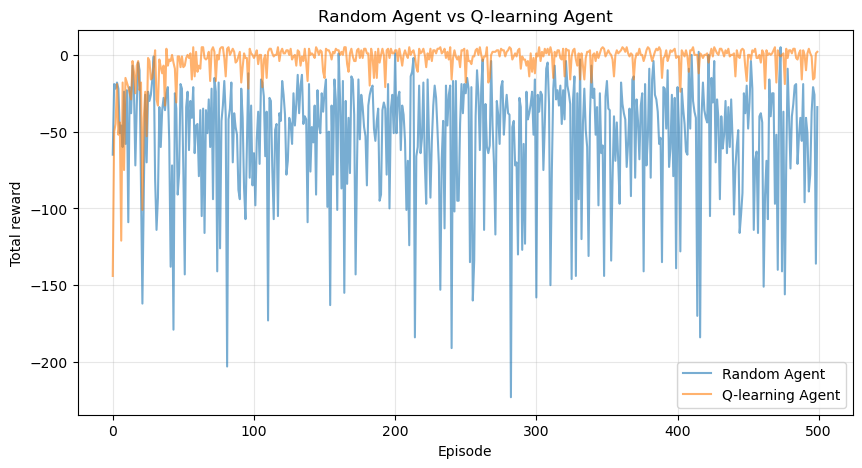

In [17]:
import matplotlib.pyplot as plt

%matplotlib inline

plt.figure(figsize=(10, 5))

plt.plot(
    random_returns,
    label="Random Agent",
    alpha=0.6
)

plt.plot(
    q_learning_returns,
    label="Q-learning Agent",
    alpha=0.6
)

plt.xlabel("Episode")
plt.ylabel("Total reward")
plt.title("Random Agent vs Q-learning Agent")
plt.legend()
plt.grid(alpha=0.3)
plt.show()